# Chapter 2. sklearn Regression — 첫 모델, 첫 Loss

**목표**: 가장 단순한 형태로 모델을 만나봅니다. 활성화 함수도 없고, 출력 범위 제한도 없는 — **그냥 숫자를 뱉는 회귀** 부터 시작합니다.

**환경**: Google Colab (GPU 불필요 — sklearn만 사용)

**예상 소요 시간**: 약 5-10분 (학습은 즉시, 데이터 로딩이 대부분)

---

## 학습 흐름

1. 🚀 **실습**: 별점 1-5를 `LinearRegression`으로 회귀
2. 🔬 **해부**: `MSELoss` 수식과 의미 — "모델 출력은 그냥 숫자다"
3. 🛠️ **변형**: 별점을 [0, 1]로 정규화 후 회귀, 그리고 그 한계

## 📊 변화추적표

| Ch | 모델 | 토크나이저 | 데이터 | Output Head | Activation | Loss |
|---|---|---|---|---|---|---|
| 1 | (TF-IDF) | `TfidfVectorizer()` | Yelp 5,000 샘플 | — | — | — |
| **2 ← 여기** | `LinearRegression()` | `TfidfVectorizer()` | Yelp (별점 1-5) | (1차원) | 없음 | `MSELoss` (sklearn: squared error) |

전체 챕터 표는 [루트 README.md](https://github.com/yoon-gu/neuqes-101#챕터별-변화추적표)를 참고하세요.

## 🔄 변경점 (Diff from Ch 1)

| 축 | Ch 1 | Ch 2 |
|---|---|---|
| 모델 | 없음 (변환만) | **`LinearRegression`** ← 추가 |
| Loss | 없음 | **`MSELoss`** ← 첫 등장 |
| 토크나이저 | TF-IDF | TF-IDF (그대로) |
| 데이터 | Yelp 5,000 | Yelp 5,000 (그대로) |

이번 챕터에서 바뀌는 것은 **모델 + Loss** 두 가지입니다 — 그러나 둘은 한 묶음으로 처음 등장하는 거라, 학습자 관점에선 사실상 "모델이 처음 생겼다"는 한 가지 변화입니다. 다음 챕터부터는 한 번에 하나씩 변합니다.

**왜 회귀부터?** 모델이 뱉는 출력은 본질적으로 그냥 숫자입니다. 분류·다중라벨·multi-task 같은 화려한 형태들은 모두 "그 숫자를 어떻게 가공해서 어떤 loss를 매길 것인가"의 변주일 뿐입니다. 가장 단순한 형태 — 활성화 함수도 없는 1차원 출력 — 부터 시작합니다.

## 📐 Loss 함수의 변화 — `MSELoss` 등장

이번 챕터의 loss는 **Mean Squared Error** 입니다.

$$L = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat y_i)^2$$

- $y_i$: 정답 (실제 별점)
- $\hat y_i$: 모델 예측

**숫자로 감 잡기** (정답이 별점 5인 한 샘플 기준, $N=1$이라 평균은 그대로):

| 정답 $y$ | 예측 $\hat y$ | 오차 $|y - \hat y|$ | 손실 $(y - \hat y)^2$ |
|---|---|---|---|
| 5 | 4 | 1 | **1** |
| 5 | 3 | 2 | **4** |
| 5 | 1 | 4 | **16** |

오차가 2배가 되면 손실은 4배, 4배가 되면 16배로 **비선형으로** 증폭됩니다. 이 제곱 항이 MSE의 성격을 결정합니다 — "조금씩 자주 틀리는 것" 보다 "어쩌다 크게 틀리는 것"을 모델이 더 강하게 회피합니다.

PyTorch에서는 `nn.MSELoss`, sklearn에서는 같은 개념이 `LinearRegression`에 내장돼 있고 평가 함수로는 `mean_squared_error`로 따로 부릅니다.

```python
# PyTorch (Ch 8 이후 등장)
criterion = nn.MSELoss()
loss = criterion(pred, target)

# sklearn (이번 챕터)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
model.fit(X, y)                            # 내부적으로 MSE 최소화
mean_squared_error(y, model.predict(X))    # 평가
```

## 🔤 토크나이저 노트

이번 챕터의 토크나이저는 **Ch 1과 동일한 `TfidfVectorizer`** 입니다. 변하는 건 그 위에 모델이 붙는다는 것뿐이라, 같은 입력 벡터에서 출발해 모델만 차이를 만들도록 합니다.

같은 문장 `"I love using Hugging Face!"` 의 토큰화 결과는 Ch 1과 똑같습니다 — 소문자, 단일 문자 제거, OOV 무시. 모델 입장에서 입력은 길이 V짜리 sparse 벡터 한 개고, 그걸 받아 **숫자 한 개** 를 뱉으면 됩니다.

> **다음 챕터(Ch 3)**: 같은 TF-IDF 그대로. 변하는 건 출력에 sigmoid가 붙고 loss가 `BCEWithLogitsLoss`로 바뀌는 것입니다.

In [1]:
!pip install -q datasets scikit-learn pandas matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# matplotlib 한글 폰트 (Colab — NanumGothic). plot 의 한국어가 □ 로 깨지지 않게.
import matplotlib.font_manager as fm, subprocess, os
_fp = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if not os.path.exists(_fp):
    subprocess.run("apt-get -qq -y install fonts-nanum", shell=True)
fm.fontManager.addfont(_fp)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

dataset = load_dataset("Yelp/yelp_review_full")
SAMPLE_SIZE = 5000
ds = dataset["train"].shuffle(seed=42).select(range(SAMPLE_SIZE))
df = ds.to_pandas()
print(f"Sample count: {len(df)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/6.72k [00:00<?, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Sample count: 5000


In [3]:
# 별점은 0-4로 저장돼 있으니 1-5로 변환
df["star"] = df["label"] + 1

# train / test split
X_text_train, X_text_test, y_train, y_test = train_test_split(
    df["text"], df["star"].astype(float),
    test_size=0.2, random_state=42,
)

# TF-IDF (Ch 1과 같은 설정)
tfidf = TfidfVectorizer(max_features=10000)
X_train = tfidf.fit_transform(X_text_train)
X_test = tfidf.transform(X_text_test)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

X_train: (4000, 10000), y_train: (4000,)
X_test:  (1000, 10000), y_test:  (1000,)


## 🚀 실습: 별점 1-5를 그대로 회귀하기

`LinearRegression`은 가중치 벡터 $w$와 편향 $b$를 학습해 다음을 출력합니다.

$$\hat y = w^\top x + b$$

활성화 함수 없음, 출력 범위 제한 없음. 정답 $y$와의 MSE를 최소화하도록 $w, b$를 푸는 게 학습의 전부입니다 (sklearn은 정규방정식으로 한 번에 풉니다).

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(f"Train MSE: {mean_squared_error(y_train, y_pred_train):.4f}")
print(f"Test  MSE: {mean_squared_error(y_test,  y_pred_test):.4f}")
print(f"Test  MAE: {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"Test  R²:  {r2_score(y_test, y_pred_test):.4f}")

Train MSE: 0.0000
Test  MSE: 1.5565
Test  MAE: 0.9952
Test  R²:  0.2139


Pred range: [-1.55, 7.15]
True range: [1, 5]


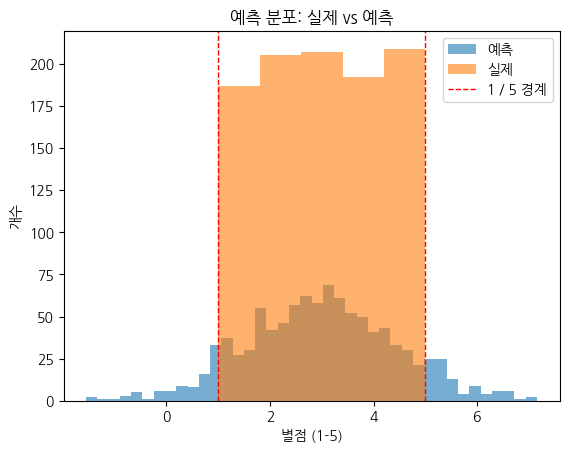

In [5]:
# 예측값이 1-5 범위를 얼마나 벗어나는지 확인
print(f"Pred range: [{y_pred_test.min():.2f}, {y_pred_test.max():.2f}]")
print(f"True range: [{y_test.min():.0f}, {y_test.max():.0f}]")

plt.hist(y_pred_test, bins=40, alpha=0.6, label="예측")
plt.hist(y_test, bins=5, alpha=0.6, label="실제")
plt.axvline(1, color="red", linestyle="--", linewidth=1, label="1 / 5 경계")
plt.axvline(5, color="red", linestyle="--", linewidth=1)
plt.xlabel("별점 (1-5)")
plt.ylabel("개수")
plt.legend()
plt.title("예측 분포: 실제 vs 예측")
plt.show()

## 🔬 해부: "출력은 그냥 숫자다"

위 분포를 보면 모델이 0.4점이나 5.7점 같은 **별점 범위 밖** 의 값도 뱉습니다. 이상해 보이지만 자연스러운 결과입니다.

`LinearRegression`이 학습한 것은 단지 "MSE를 최소화하는 가중합"이지, "출력값이 1과 5 사이여야 한다"는 제약을 듣지 않습니다. 모델은 활성화 함수 없이 $w^\top x + b$를 그대로 뱉을 뿐이라 음수도 5 초과도 모두 가능한 결과입니다.

이게 **회귀의 본질** 입니다. 출력 범위 제약은 모델이 아니라 사람이 따로 입혀야 합니다 — clipping 같은 후처리, 혹은 sigmoid 같은 활성화 함수로요.

In [6]:
# sklearn의 mean_squared_error가 내부에서 뭘 계산하는지 직접 재현
manual_mse = ((y_test - y_pred_test) ** 2).mean()
sklearn_mse = mean_squared_error(y_test, y_pred_test)

print(f"Manual MSE: {manual_mse:.6f}")
print(f"sklearn MSE: {sklearn_mse:.6f}")
print(f"Diff:        {abs(manual_mse - sklearn_mse):.2e}")

Manual MSE: 1.556471
sklearn MSE: 1.556471
Diff:        0.00e+00


## 🛠️ 변형: 별점을 [0, 1]로 정규화

회귀의 출력이 어차피 임의 범위를 갖는다면, 정답 라벨을 일부러 [0, 1]로 정규화하면 어떻게 될까요? 별점 1-5를 4로 나눠 [0, 1] 사이로 압축합니다.

$$y' = \frac{y - 1}{4} \in [0, 1]$$

이게 의미 있는 이유는 **다음 챕터의 다리** 가 되기 때문입니다. Ch 3에서 sigmoid를 출력에 붙여 강제로 [0, 1]로 누를 텐데, 그때 정답 라벨도 [0, 1] 형식이어야 호환됩니다.

In [7]:
y_train_norm = (y_train - 1) / 4   # 1-5 → 0-1
y_test_norm = (y_test - 1) / 4

model_norm = LinearRegression()
model_norm.fit(X_train, y_train_norm)

y_pred_norm = model_norm.predict(X_test)

# 정규화 공간에서의 MSE
print(f"Test MSE (normalized space): {mean_squared_error(y_test_norm, y_pred_norm):.4f}")

# 원래 별점 공간으로 되돌렸을 때 MSE 비교
y_pred_back = y_pred_norm * 4 + 1
print(f"Test MSE (back to star space): {mean_squared_error(y_test, y_pred_back):.4f}")
print(f"Test MSE (no normalization):    {mean_squared_error(y_test, y_pred_test):.4f}")

Test MSE (normalized space): 0.0973
Test MSE (back to star space): 1.5565
Test MSE (no normalization):    1.5565


In [8]:
# 정규화한 모델도 여전히 [0, 1]을 벗어나는 값을 뱉는가?
print(f"Normalized model pred range: [{y_pred_norm.min():.3f}, {y_pred_norm.max():.3f}]")
print(f"Ideal range: [0, 1]")

n_below = (y_pred_norm < 0).sum()
n_above = (y_pred_norm > 1).sum()
print(f"\nPredictions < 0: {n_below} ({n_below / len(y_pred_norm):.1%})")
print(f"Predictions > 1: {n_above} ({n_above / len(y_pred_norm):.1%})")

Normalized model pred range: [-0.638, 1.538]
Ideal range: [0, 1]

Predictions < 0: 85 (8.5%)
Predictions > 1: 92 (9.2%)


**관찰**: 정답 라벨을 [0, 1]로 압축해도 모델 출력은 여전히 그 범위를 벗어납니다. 가중합을 그대로 뱉는 한 어떤 라벨 스케일링으로도 [0, 1] 안에 가둘 수 없습니다.

그렇다면 출력을 강제로 [0, 1] 사이로 누르려면 **활성화 함수** 가 필요합니다.

> **다음 챕터(Ch 3) 예고**: `LogisticRegression`이 등장합니다. 모델 구조는 거의 그대로지만 출력 직전에 **sigmoid** 가 붙어 [0, 1]을 강제하고, loss는 MSE 대신 **`BCEWithLogitsLoss`** (sklearn: log loss)로 바뀝니다. 라벨도 [0, 1] 정규화 대신 **0/1 이진** 으로 바뀝니다.

## 📦 이번 챕터에 등장한 라이브러리

| 이름 | 한 줄 설명 | 다음 챕터에서 |
|---|---|---|
| `sklearn.linear_model.LinearRegression` | MSE 최소화 1차원 회귀 | sklearn 모델 라인업의 시작, BERT는 Ch 8부터 같은 역할 |
| `sklearn.model_selection.train_test_split` | 훈련/평가 분할 | Ch 3-5에서 계속 사용 |
| `sklearn.metrics.mean_squared_error` | MSE 평가 | Ch 8 BERT 회귀에서도 평가 지표로 등장 |
| `sklearn.metrics.mean_absolute_error` | MAE 평가 (참고용) | — |
| `sklearn.metrics.r2_score` | 결정계수 R² | — |

## 🎯 체크포인트 질문

1. `LinearRegression`은 왜 활성화 함수가 없나요? 회귀에서 활성화 함수가 빠지면 어떤 자유도가 생기나요?
2. MSE를 수식으로 적어보세요. 큰 오차에 큰 페널티를 주는 이유는 어느 항에서 오나요?
3. 별점을 [0, 1]로 정규화한 모델의 예측값이 여전히 그 범위를 벗어나는 이유는 무엇인가요?
4. 같은 데이터를 정규화 없이 학습한 모델과 정규화 후 학습한 모델은 (후처리로 되돌렸을 때) Test MSE가 거의 같습니다. 왜 그런가요?

## ❓ FAQ

### Q1. (이론) MSE 대신 MAE를 쓰면 어떻게 다른가요?

MSE는 오차를 제곱하지만 MAE(Mean Absolute Error)는 절댓값만 취합니다.

$$\text{MSE} = \frac{1}{N}\sum (y_i - \hat y_i)^2 \qquad \text{MAE} = \frac{1}{N}\sum |y_i - \hat y_i|$$

차이는 두 가지입니다.

1. **outlier 민감도**: MSE는 큰 오차를 제곱해 압도적으로 큰 페널티를 주므로 outlier 한 개가 모델 전체를 끌어당깁니다. MAE는 선형이라 outlier에 덜 민감합니다 (robust).
2. **gradient 형태**: MSE의 gradient는 $\hat y - y$ (오차에 비례), MAE는 $\pm 1$ (오차와 무관한 상수). 그래서 SGD 기반 학습에서 MAE는 미세 조정이 어려울 수 있고 0 근처에서 비미분(non-differentiable)이라 변형(Huber loss 등)이 자주 쓰입니다.

```python
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_pred_test)
```

### Q2. (이론) 별점을 [0, 1]로 정규화하면 학습이 더 잘 되나요?

`LinearRegression`은 정규방정식(closed-form)으로 풀기 때문에 라벨 스케일이 결과에 영향을 거의 주지 않습니다. 위 셀에서 보았듯 정규화 공간에서 학습한 모델을 원래 별점 공간으로 되돌리면 정규화 없이 학습한 모델과 거의 같은 MSE가 나옵니다.

라벨 정규화가 의미 있는 경우는 따로 있습니다.

- **SGD 기반 학습 (BERT 포함)**: 라벨 스케일이 크면 gradient도 커져 학습률 조정이 까다로워집니다. [0, 1] 정규화가 안정성에 도움.
- **다른 loss와 호환**: BCE/sigmoid는 [0, 1] 라벨이 필요. 이번 챕터의 정규화는 다음 챕터를 위한 다리.
- **해석 편의**: [0, 1]은 "확률"처럼 읽혀 다른 점수와 비교할 때 편함.

### Q3. (실무) 학습이 너무 빨리 끝나는데 정상인가요?

네, 정상입니다. `LinearRegression`은 SGD가 아니라 **정규방정식(normal equation)** 으로 한 번에 답을 내는 닫힌 형태 풀이입니다.

$$w = (X^\top X)^{-1} X^\top y$$

5,000 샘플 × 10,000 feature(sparse) 정도는 1초 안에 끝납니다. BERT 파인튜닝은 같은 데이터로 5-10분 걸리는 것과 비교하면 수백 배 빠릅니다 — 모델 표현력이 다르기 때문입니다.

### Q4. (이론) `LinearRegression`은 왜 활성화 함수가 없나요?

회귀의 정의가 "임의의 실수를 예측한다"이기 때문입니다. 활성화 함수는 출력 범위에 제약을 거는 도구라(sigmoid → [0,1], tanh → [-1,1], softmax → 확률 분포), 범위 제약이 필요 없는 회귀에서는 자연스럽게 빠집니다.

오히려 헷갈리는 건 분류 쪽입니다. 분류는 출력이 "확률"이어야 하므로 sigmoid/softmax가 강제로 들어가는 거지, 활성화 함수가 더 "원본" 형태인 게 아닙니다. **회귀의 비활성 출력이 가장 단순한 형태** 라고 보면 됩니다.

### Q5. (실무) 예측값이 5보다 크거나 1보다 작게 나오는데 어떻게 하나요?

세 가지 선택지가 있습니다.

1. **그대로 둔다 (가장 흔함)**: 평가 지표(MSE, MAE)는 범위 밖 값도 그대로 받습니다. 회귀에서는 범위 이탈을 굳이 막지 않는 게 일반적.
2. **clip으로 잘라낸다**: 후처리로 [1, 5] 안으로 강제.

```python
y_pred_clipped = np.clip(y_pred_test, 1, 5)
print(f"Test MSE (clip 후): {mean_squared_error(y_test, y_pred_clipped):.4f}")
```

3. **출력에 sigmoid를 붙인다**: 다음 챕터의 방법. 활성화 함수로 모델 단계에서 [0, 1]을 강제.

선택은 목적에 따릅니다 — UI에 보여줄 점수면 clip이 깔끔하고, 다른 모델과 합쳐 학습 신호로 쓸 거면 그대로 둡니다.

### Q6. (이론) 별점은 1, 2, 3, 4, 5의 정수인데 회귀로 다루는 게 맞나요? 분류가 더 낫지 않나요?

둘 다 가능하고, 절대 정답은 없습니다.

- **회귀가 자연스러운 이유**: 별점은 **순서(ordinal)** 가 있습니다. 4점과 5점이 가깝다는 정보를 회귀는 보존합니다 (loss가 거리 기반).
- **분류가 자연스러운 이유**: 클래스 사이 간격이 균등하지 않을 수 있습니다. 1점과 2점의 차이, 4점과 5점의 차이가 같은 의미일까요? 사람마다 다릅니다. 분류는 클래스 간 거리를 가정하지 않습니다.

이 커리큘럼에서는 두 관점을 모두 보여줍니다 — Ch 2 (회귀) → Ch 5 (5클래스 분류). 같은 데이터를 두 방식으로 다룰 때 결과가 어떻게 달라지는지 비교하면 회귀와 분류의 차이가 손에 잡힙니다.

## 🚀 삽질 코너 (선택)

다음 코드를 돌려보고, 두 모델의 결과가 같은지 다른지 예측해보세요.

```python
# 모델 A: 별점 1-5 그대로 학습
model_a = LinearRegression().fit(X_train, y_train)

# 모델 B: 정답에 100을 곱해서 학습 (별점 100-500처럼)
model_b = LinearRegression().fit(X_train, y_train * 100)

pred_a = model_a.predict(X_test)
pred_b = model_b.predict(X_test) / 100   # 다시 1-5 스케일로

print(f"A vs B 예측 차이 최대: {np.abs(pred_a - pred_b).max():.2e}")
```

힌트: 닫힌 형태 풀이에서 라벨에 상수를 곱하면 가중치도 같은 비율로 바뀔 뿐, 예측을 같은 스케일로 되돌리면 정확히 같은 값이 나와야 합니다.

## 다음 챕터 예고

**Chapter 3. sklearn Binary — 출력에 sigmoid가 붙다**

- 별점을 4-5점 → 1, 1-2점 → 0으로 이진화 (3점은 제외)
- `LogisticRegression`: 출력에 **sigmoid** 가 붙고, loss는 **`BCEWithLogitsLoss`** (sklearn: log loss)로 바뀜
- 처음으로 "확률"을 출력하는 모델 — `predict_proba`로 확인
- 변경점은 **출력 형태 + Loss** 두 가지 (모델·토크나이저는 그대로, 데이터는 이진화로 가공)